# Homework Starter — Stage 03: Python Fundamentals

## Instructions
Fill in the cells below to complete your homework. Refer to lecture examples.

In [ ]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. NumPy Operations

In [2]:
# TODO: Create a NumPy array and perform vectorized operations

# Create a NumPy array and perform vectorized operation
data_arr = np.arange(1, 1000001)

# Loop implementation
def compute_loop(arr):
    result = []
    for x in arr:
        result.append(x ** 2 + 2 * x + 1)
    return result

# Vectorized implementation
def compute_vectorized(arr):
    return arr ** 2 + 2 * arr + 1

compute_vectorized(data_arr)

array([            4,             9,            16, ...,  999998000001,
       1000000000000, 1000002000001], shape=(1000000,))

## 2. Compare Loop vs Vectorization

In [3]:
# TODO: Compare speed using %timeit

print("Timing Loop Execution:")
%timeit compute_loop(data_arr)

print("\nTiming Vectorized Execution:")
%timeit compute_vectorized(data_arr)

Timing Loop Execution:
135 ms ± 518 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)

Timing Vectorized Execution:
2.6 ms ± 31.1 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## 3. Load and Inspect Dataset

In [6]:
# TODO: Load CSV and inspect with .head(), .info(), .describe()

# Load dataset from data/raw/
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_path = ROOT / "data" / "raw" / "starter_data.csv"

# Fallback to starter_data.csv if sp500 is not in homework folder
if not data_path.exists():
    data_path = ROOT.parent.parent / "homework" / "homework03" / "data" / "raw" / "starter_data.csv"

df = pd.read_csv(data_path)

print("Dataset Head:")
print(df.head())

print("\nDataset Info:")
df.info()

print("\nNumeric Summary:")
print(df.describe())

Dataset Head:
  category  value        date
0        A     10  2025-08-01
1        B     15  2025-08-02
2        A     12  2025-08-03
3        B     18  2025-08-04
4        C     25  2025-08-05

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  10 non-null     object
 1   value     10 non-null     int64 
 2   date      10 non-null     object
dtypes: int64(1), object(2)
memory usage: 368.0+ bytes

Numeric Summary:
           value
count  10.000000
mean   17.600000
std     7.381659
min    10.000000
25%    12.250000
50%    14.500000
75%    23.250000
max    30.000000


## 4. Summary Statistics and Groupby

In [7]:
# TODO: Perform groupby and save output to data/processed/

summary_df = df.groupby('category')['value'].agg(['count', 'mean', 'std', 'min', 'max']).reset_index()
print("Groupby Summary Statistics (By Category):")
print(summary_df)

# Save processed output to data/processed/summary.csv
output_dir = ROOT / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)
summary_file = output_dir / "summary.csv"
summary_df.to_csv(summary_file, index=False)
print(f"\nSaved summary statistics to: {summary_file}")

Groupby Summary Statistics (By Category):
  category  count       mean       std  min  max
0        A      4  11.500000  1.290994   10   13
1        B      3  15.666667  2.081666   14   18
2        C      3  27.666667  2.516611   25   30

Saved summary statistics to: /Users/cloudnine_7/bootcamp_elrie_lin/homework/homework03/data/processed/summary.csv


## Bonus (Visualization)

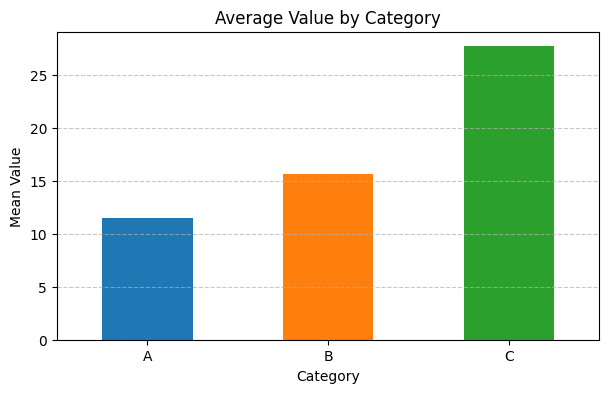

Plot saved to: /Users/cloudnine_7/bootcamp_elrie_lin/homework/homework03/reports/category_summary.png


In [8]:
# Create a bar plot comparing average value per category
category_means = df.groupby('category')['value'].mean()

plt.figure(figsize=(7, 4))
category_means.plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Average Value by Category')
plt.xlabel('Category')
plt.ylabel('Mean Value')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save plot to reports directory
reports_dir = ROOT / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)
plot_path = reports_dir / "category_summary.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Plot saved to: {plot_path}")

## 5. Reusable Functions

In [9]:
import sys

# Add src to system path to import custom modules
sys.path.append(str(ROOT / "src"))

from utils import get_summary_stats
print("Packages and custom utilities loaded successfully.")

Packages and custom utilities loaded successfully.


In [10]:
# Perform groupby aggregation by category using custom utility function
my_summary_df = get_summary_stats(df, group_col='category', numeric_col='value')
print("Groupby Summary Statistics (By Category):")
print(my_summary_df)

Groupby Summary Statistics (By Category):
  category  count       mean       std  min  max
0        A      4  11.500000  1.290994   10   13
1        B      3  15.666667  2.081666   14   18
2        C      3  27.666667  2.516611   25   30
